绘图

In [142]:
%matplotlib inline
import matplotlib
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path
import boule as bl
import pandas as pd
import lonlat_labels as label
import cartopy.crs as ccrs
from plot_boundary import plot_boundaries_folder_on_ax
from matplotlib.colors import LightSource
import pyshtools as pysh
from plot_basins import add_basin

In [143]:
# 全体设置
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Songti SC"],  # Mac 自带宋体
    "axes.unicode_minus": False,

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.2,
    "ytick.major.size": 3.2,
    "xtick.direction": "out",
    "ytick.direction": "out",

    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


# 月球主要撞击盆地列表，包含名称、中心经纬度和直径（单位：km）
basins = [
    ("IMB", "Imbrium", 33.0, -18.0, 580),
    ("SER", "Serenitatis", 27.0, 19.0, 370),
    ("CRI", "Crisium", 17.5, 58.5, 530),
    ("SMY", "Smythii", -2.0, 87.0, 420),
    ("HUM", "Humboldtianum", 61.0, 84.0, 300),
    ("MOS", "Moscoviense", 26.0, 147.0, 222.5),
    ("FSH", "Freundlich-Sharonov", 18.5, 175.0, 300),
    ("KOR", "Korolev", -4.5, -157.0, 220),
    ("HER", "Hertzsprung", 1.5, -128.5, 285),
    ("ORI", "Orientale", -20.0, -95.0, 465),
    ("HUMO", "Humorum", -24.0, -39.5, 410),
    ("NEC", "Nectaris", -16.0, 34.0, 430),
    ("APO", "Apollo", -36.0, -151.0, 252.5),
    ("MR", "Mendel-Rydberg", -50.0, -94.0, 315),
    # ("SAM","",-53,-169,1200)
]

apollo_sites = {
    "Apollo 12": {"lat": -3.01, "lon": -23.42},
    "Apollo 14": {"lat": -3.64, "lon": -17.47},
    "Apollo 15": {"lat": 26.13, "lon":   3.63},
    "Apollo 16": {"lat": -8.97, "lon":  15.50},
}

xlocs = np.arange(-180, 181, 30)
xlocs = xlocs[(xlocs != 90) & (xlocs != -90)]
ylocs = np.arange(-90, 91, 30)

In [144]:
dpi=300

In [145]:
# read data
LDEM=pysh.datasets.Moon.LDEM_shape_pa()
topo_grid=LDEM.expand(grid='DH2',lmax=1200,extend=False)
topo=topo_grid.to_xarray()

fig=plt.figure(figsize=(8, 10))
ls=LightSource(azdeg=315, altdeg=45)
# 计算网格
lat_mid=float(topo.lat.mean())
dx=np.deg2rad(float(topo.lon.diff('lon').mean()))*1737.4e3
dy=np.deg2rad(float(topo.lat.diff('lat').mean()))*1737.4e3

hillshade=ls.hillshade(np.array(topo),vert_exag=10,dx=dx,dy=dy)
hillshade_alpha=0.35

def add_hillshade(ax):
    ax.pcolormesh(topo.lon, topo.lat, hillshade,
                  transform=ccrs.PlateCarree(),
                  cmap='gray', vmin=0, vmax=1,
                  alpha=hillshade_alpha, shading='auto', zorder=2)
    
def add_panel_label(ax, label, x=0.02, y=0.95):
    ax.text(x, y, label, transform=ax.transAxes, fontsize=15, fontweight='bold', va='top', ha='left')

def find_extreme(da):
    Z=da.values
    lat=da.lat
    lon=da.lon
    mask = np.isfinite(Z)

    # 最大
    imax = np.nanargmax(np.where(mask, Z, np.nan))
    ilat_max, ilon_max = np.unravel_index(imax, Z.shape)
    lat_max = float(lat[ilat_max])
    lon_max = float(lon[ilon_max])
    val_max = float(Z[ilat_max, ilon_max])

    # 最小
    imin = np.nanargmin(np.where(mask, Z, np.nan))
    ilat_min, ilon_min = np.unravel_index(imin, Z.shape)
    lat_min = float(lat[ilat_min])
    lon_min = float(lon[ilon_min])
    val_min = float(Z[ilat_min, ilon_min])

    return val_max,lon_max,lat_max,val_min,lon_min,lat_min

def mark_extreme(ax, lon0, lat0, value, marker, color, text_dx=2.0, text_dy=2.0):
    # 标记点（不那么夸张，更论文）
    ax.scatter(
        [lon0], [lat0],
        transform=ccrs.PlateCarree(),
        s=70,
        marker=marker,
        facecolor=color,
        edgecolor="0.1",
        linewidth=0.8,
        zorder=10
    )

    # 数值标注（稍微偏移，避免压在点上）
    ax.text(
        lon0 + text_dx, lat0 + text_dy,
        f"{value:.1f}",
        transform=ccrs.PlateCarree(),
        fontsize=9,
        ha="right", va="bottom",
        color="0.1",
        bbox=dict(facecolor="white", alpha=0.45, edgecolor="none", pad=0.8),
        zorder=11
    )

def plot_hemisphere_pair(
    data_list,
    panel_labels=None,
    cmap='terrain',
    vmin=None, vmax=None,
    topo=None,
    hillshade_alpha=0.3,
    basins=None,
    apollo_sites=None,
    xlocs=None, ylocs=None,
    cbar_label="Crustal Thickness (km)",
    mark_extremes=True,
    boundaries_folder='data',
    figsize=None,
    savepath=None,
    dpi=600,
):
    """
    绘制一组或多组"近月面 + 远月面"半球对比图。

    参数
    ----
    data_list : list of xarray.DataArray
        要绘制的数据列表,每个元素会生成一行(近月面 + 远月面 两张子图)。
        例如 [crustthick_spherical] 生成 1 行 2 子图;
              [crustthick_spherical, crustthick_tesseroid] 生成 2 行 4 子图。
    panel_labels : list of str, optional
        每个子图左上角的标签,如 ["(a)", "(b)", "(c)", "(d)"]。
        长度应为 len(data_list) * 2。默认自动生成 (a)(b)(c)...
    cmap : str
        colormap 名称
    vmin, vmax : float, optional
        色标范围。若为 None,则自动取所有数据的最小/最大值
    topo : xarray.DataArray, optional
        地形数据,用于生成 hillshade。若为 None 则不画 hillshade
    hillshade_alpha : float
        hillshade 的透明度
    basins : list of tuples, optional
        盆地信息 [(abbr, fullname, lat0, lon0, r_km), ...]
    apollo_sites : optional
        Apollo 着陆点信息(传给 label.plot_apollo_sites)
    xlocs, ylocs : array-like, optional
        经纬度刻度位置。默认 -180~180 / -90~90 每 30 度
    cbar_label : str
        色标标签文字
    mark_extremes : bool
        是否标注每组数据的最大/最小值
    boundaries_folder : str
        边界文件所在文件夹
    figsize : tuple, optional
        画布尺寸。若为 None 则按行数自动计算
    savepath : str, optional
        保存路径。若为 None 则不保存
    dpi : int
        保存分辨率

    返回
    ----
    fig, axes : matplotlib Figure 和 axes 列表
    """
    n_rows = len(data_list)

    # 默认参数
    if xlocs is None:
        xlocs = np.arange(-180, 181, 30)
        xlocs = xlocs[(xlocs != 90) & (xlocs != -90)]
    if ylocs is None:
        ylocs = np.arange(-90, 91, 30)
    if panel_labels is None:
        panel_labels = [f"({chr(ord('a') + i)})" for i in range(n_rows * 2)]
    if figsize is None:
        figsize = (8, 5 * n_rows)
    if vmin is None:
        vmin = float(np.nanmin([np.nanmin(d) for d in data_list]))
    if vmax is None:
        vmax = float(np.nanmax([np.nanmax(d) for d in data_list]))

    # 计算 hillshade(如果给了 topo)
    hillshade = None
    if topo is not None:
        ls = LightSource(azdeg=315, altdeg=45)
        dx = np.deg2rad(float(topo.lon.diff('lon').mean())) * 1737.4e3
        dy = np.deg2rad(float(topo.lat.diff('lat').mean())) * 1737.4e3
        hillshade = ls.hillshade(np.array(topo), vert_exag=10, dx=dx, dy=dy)

    fig = plt.figure(figsize=figsize)
    axes = []
    pm_first = None  # 用于共享 colorbar

    for row_idx, da in enumerate(data_list):
        # 近月面 (central_longitude=0) 和 远月面 (central_longitude=180)
        for col_idx, central_lon in enumerate([0, 180]):
            subplot_idx = row_idx * 2 + col_idx + 1
            ax = plt.subplot(
                n_rows, 2, subplot_idx,
                projection=ccrs.Orthographic(central_longitude=central_lon, central_latitude=0)
            )
            ax.set_global()

            pm = ax.pcolormesh(
                da.lon, da.lat, da,
                transform=ccrs.PlateCarree(),
                cmap=cmap, shading="auto",
                vmin=vmin, vmax=vmax,
            )
            if pm_first is None:
                pm_first = pm

            # hillshade 叠加
            if hillshade is not None:
                ax.pcolormesh(
                    topo.lon, topo.lat, hillshade,
                    transform=ccrs.PlateCarree(),
                    alpha=hillshade_alpha,
                    cmap='gray', vmin=0, vmax=1,
                    shading='auto',
                )

            # 子图标签
            add_panel_label(ax, panel_labels[subplot_idx - 1],x=0)

            # 网格线
            ax.gridlines(
                xlocs=np.arange(-180, 181, 30),
                ylocs=np.arange(-90, 91, 30),
                draw_labels=False,
                linewidth=0.5, color='gray', alpha=0.5, linestyle='--',
            )

            # 经纬度标签 + 边界
            if col_idx == 0:  # 近月面
                label.add_lat_labels_on_limb(ax, ylocs, side="left",
                                             offset_frac=0.07, text_kwargs={"fontsize": 12})
                label.add_lon_labels_on_equator(ax, xlocs, text_kwargs={"fontsize": 12})
                if apollo_sites is not None:
                    label.plot_apollo_sites(ax, apollo_sites, show_labels=True)
            else:  # 远月面
                label.add_lat_labels_on_limb(ax, ylocs, side="right",
                                             offset_frac=0.07, text_kwargs={"fontsize": 12})
                label.add_lon_labels_on_equator(ax, xlocs, central_lonlat=(180, 0),
                                                text_kwargs={"fontsize": 12})

            plot_boundaries_folder_on_ax(
                ax, boundaries_folder,
                thick_keywords=("SPATU", "MTU"),
                linewidth_thick=1.2, linewidth_thin=0.8,
            )

            # 盆地
            if basins is not None:
                for (abbr, fullname, lat0, lon0, r_km) in basins:
                    offside = (0, -10) if abbr == "NEC" else (0, 10)
                    add_basin(ax, abbr, lat0, lon0, r_km,
                              lw=1, alpha=0.8, n_samples=100, label_offset=offside)

            axes.append(ax)

        # 标记每行数据的极值(画在该行的两个子图上)
        if mark_extremes:
            val_max, lon_max, lat_max, val_min, lon_min, lat_min = find_extreme(da)
            for ax in axes[-2:]:  # 当前行的两个 ax
                mark_extreme(ax, lon_max, lat_max, val_max, "^", "red")
                mark_extreme(ax, lon_min, lat_min, val_min, "v", "limegreen", text_dx=5)

    # 共享 colorbar
    cbar = fig.colorbar(pm_first, ax=axes, location='bottom',
                        pad=0.05, shrink=1, aspect=40)
    cbar.set_label(cbar_label, fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    if savepath is not None:
        fig.savefig(savepath, dpi=dpi, bbox_inches="tight")

    return fig, axes, cbar

def weighted_mean_std(data, weights):

    mu = np.average(data, weights=weights)

    sigma = np.sqrt(
        np.average((data - mu)**2, weights=weights)
    )

    return mu, sigma

def plot_hist(ax, data, weights, title, bin_edges,
              line_color="0.2",xlabel="月壳厚度 (km)"):
    mask = np.isfinite(data) & np.isfinite(weights)

    data = data[mask]
    weights = weights[mask]
    mu, sigma = weighted_mean_std(data, weights)

    ax.hist(data, bins=bin_edges,
                color="steelblue",alpha=0.78,
                edgecolor="white",linewidth=0.35,
                density=True,label="global",weights=weights)

    ax.axvline(mu, color=line_color, linewidth=1.6)
    ax.axvline(mu - sigma, color=line_color,
               linewidth=1.2, linestyle="--")
    ax.axvline(mu + sigma, color=line_color,
               linewidth=1.2, linestyle="--")

    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("PDF", fontsize=11)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.text(
        0.02, 0.78,
        f"N={data.size}\nμ={mu:.2f}\nσ={sigma:.2f}",
        transform=ax.transAxes,
        va="top",
        fontsize=10
    )

    return ax

<Figure size 800x1000 with 0 Axes>

# 数据图

## 1. topographic

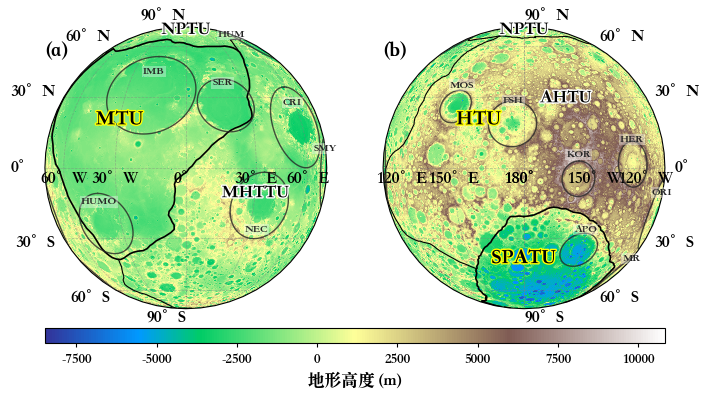

In [146]:
topo_plot=topo
topo_plot.values=topo_plot.values-bl.Moon2015.mean_radius

fig, axes, cbar = plot_hemisphere_pair(
    data_list=[topo],
    cmap='terrain',
    cbar_label="地形高度 (m)",
    mark_extremes=False,
    basins=basins,
    savepath=None,
)

import matplotlib.patheffects as pe

axes[0].text(
    -30, 20, "MTU",
    transform=ccrs.PlateCarree(),
    fontsize=15,
    color="black",          # 填充色
    ha="center", va="center",
    path_effects=[
        pe.withStroke(linewidth=2, foreground="yellow")  # 描边
    ],
    zorder=10,
)

axes[1].text(
    160, 20, "HTU",
    transform=ccrs.PlateCarree(),
    fontsize=15,
    color="black",          # 填充色
    ha="center", va="center",
    path_effects=[
        pe.withStroke(linewidth=2, foreground="yellow")  # 描边
    ],
    zorder=10,
)

axes[1].text(
    180, -40, "SPATU",
    transform=ccrs.PlateCarree(),
    fontsize=15,
    color="black",          # 填充色
    ha="center", va="center",
    path_effects=[
        pe.withStroke(linewidth=2, foreground="yellow")  # 描边
    ],
    zorder=10,
)

axes[0].text(
    30, -10, "MHTTU",
    transform=ccrs.PlateCarree(),
    fontsize=13,
    color="black",          # 填充色
    ha="center", va="center",
    path_effects=[
        pe.withStroke(linewidth=2, foreground="white")  # 描边
    ],
    zorder=10,
)

axes[0].text(
    0, 80, "NPTU",
    transform=ccrs.PlateCarree(),
    fontsize=13,
    color="black",          # 填充色
    ha="center", va="center",
    path_effects=[
        pe.withStroke(linewidth=2, foreground="white")  # 描边
    ],
    zorder=10,
)

axes[1].text(
    180, 80, "NPTU",
    transform=ccrs.PlateCarree(),
    fontsize=13,
    color="black",          # 填充色
    ha="center", va="center",
    path_effects=[
        pe.withStroke(linewidth=2, foreground="white")  # 描边
    ],
    zorder=10,
)

axes[1].text(
    -160, 30, "AHTU",
    transform=ccrs.PlateCarree(),
    fontsize=13,
    color="black",          # 填充色
    ha="center", va="center",
    path_effects=[
        pe.withStroke(linewidth=2, foreground="white")  # 描边
    ],
    zorder=10,
)

fig.savefig("figure/figure1_topodata.png",dpi=dpi, bbox_inches="tight")

## 2. freeair data

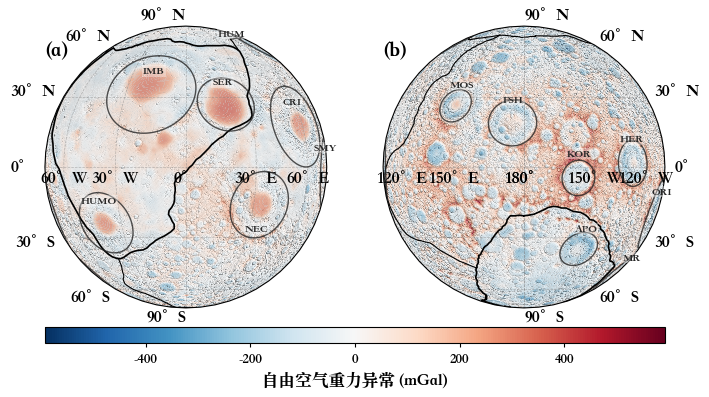

In [147]:
height=11e3

GRGM1200B=pysh.datasets.Moon.GRGM1200B()
GRGM1200B.set_omega(bl.Moon2015.angular_velocity)
GRGM1200B=GRGM1200B.change_ref(gm=bl.Moon2015.geocentric_grav_const,r0=bl.Moon2015.radius)
GRGM1200B_grid=GRGM1200B.expand(lmax=1200,a=bl.Moon2015.mean_radius+height,f=0,normal_gravity=False,extend=False)
GRGM1200B_xr=GRGM1200B_grid.to_xarray()

lat=np.array(GRGM1200B_xr.lat)
lon=np.array(GRGM1200B_xr.lon)

LON,LAT=np.meshgrid(lon,lat)

coor_normal_gravity=(LON,LAT,(height)*np.ones_like(LON))

normal_gravity=bl.Moon2015.normal_gravity(coor_normal_gravity)

data=-GRGM1200B_xr.radial.data*1e5-normal_gravity

freeair=xr.DataArray(data,dims=('lat','lon'),coords={'lat': GRGM1200B_xr.lat,'lon':GRGM1200B_xr.lon})

v=np.max(np.abs(data))

fig, axes, cbar = plot_hemisphere_pair(
    data_list=[freeair],
    cmap='RdBu_r',
    cbar_label="自由空气重力异常 (mGal)",
    topo=topo,
    hillshade_alpha=0.35,
    mark_extremes=False,
    basins=basins,
    vmax=v,vmin=-v,
    dpi=dpi,
    savepath="figure/figure2_freeair.png",
)

## 3. crustaldensity

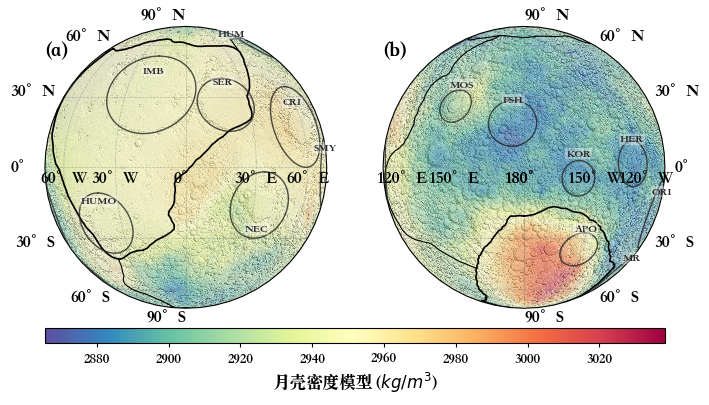

In [148]:
densityfile="density_no_mare_n3000_f3050_719.sh"
density=pysh.SHCoeffs.from_file(densityfile,lmax=719)
density_grid=density.expand(grid='DH2',lmax=719,extend=False)
density_xr=density_grid.to_xarray()

fig, axes, cbar = plot_hemisphere_pair(
    data_list=[density_xr],
    cmap='Spectral_r',
    cbar_label="月壳密度模型 ($kg/m^3$)",
    topo=topo,
    hillshade_alpha=0.35,
    mark_extremes=False,
    basins=basins,
    dpi=dpi,
    savepath="figure/figure3_crustaldensity.png",
)

## 4. sphericalbouguer

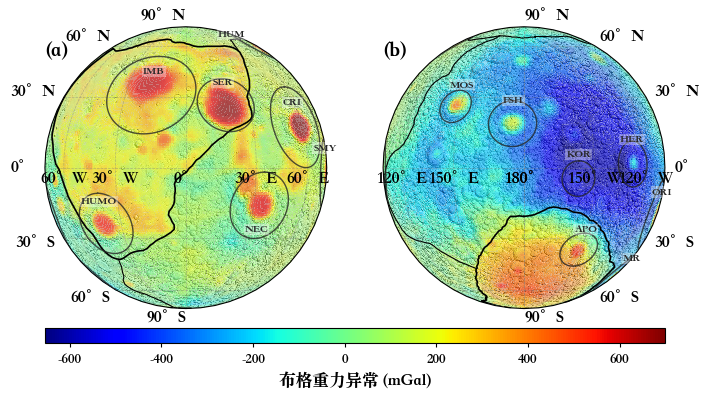

In [149]:
df=pd.read_csv("boueguer_frenquency_11km_1deg.csv")

lat_raw=np.sort(df['lat'].unique())
lon_raw=np.sort(df['lon'].unique())

bouguer_grid=df.pivot(index='lat',columns='lon',values='deltaN').loc[lat_raw,lon_raw].values


bouguer_spherical=xr.DataArray(bouguer_grid,dims=('lat','lon'),coords={'lat':lat_raw,'lon':lon_raw})

fig, axes, cbar = plot_hemisphere_pair(
    data_list=[bouguer_spherical],
    cmap='jet',
    cbar_label="布格重力异常 (mGal)",
    topo=topo,
    hillshade_alpha=0.35,
    mark_extremes=False,
    basins=basins,
    dpi=dpi,
    savepath="figure/figure4_sphericalbouguer.png",
)

## 6. tesseroidbouguer

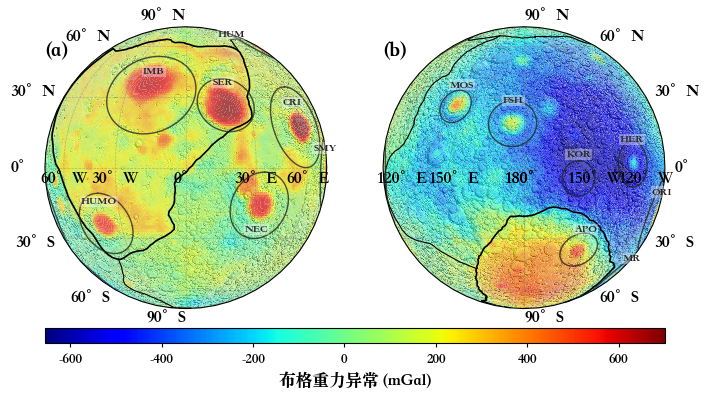

In [150]:
df=pd.read_csv("boueguer_tesseroid_11km_1deg.csv")

lat_raw=np.sort(df['lat'].unique())
lon_raw=np.sort(df['lon'].unique())

bouguer_grid=df.pivot(index='lat',columns='lon',values='deltaN').loc[lat_raw,lon_raw].values


bouguer_tesseroid=xr.DataArray(bouguer_grid,dims=('lat','lon'),coords={'lat':lat_raw,'lon':lon_raw})

fig, axes, cbar = plot_hemisphere_pair(
    data_list=[bouguer_tesseroid],
    cmap='jet',
    cbar_label="布格重力异常 (mGal)",
    topo=topo,
    hillshade_alpha=0.35,
    mark_extremes=False,
    basins=basins,
    dpi=dpi,
    savepath="figure/figure6_tesseroidbouguer.png",
)

## 7.diffbouguer

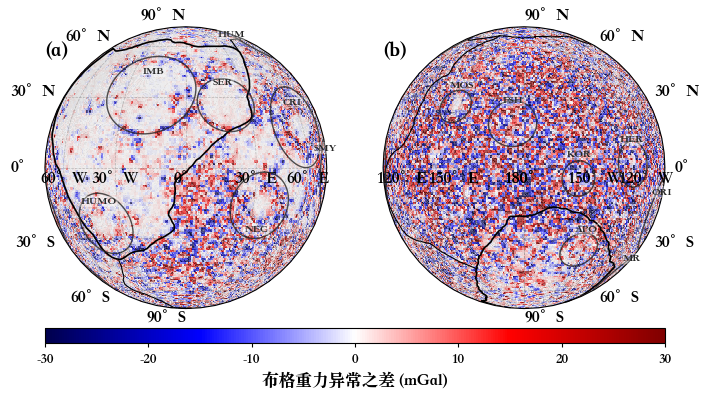

In [151]:
bouguer_spherical=bouguer_spherical.interp_like(bouguer_tesseroid)

diffbouguer=bouguer_spherical-bouguer_tesseroid

v=30

fig, axes, cbar = plot_hemisphere_pair(
    data_list=[diffbouguer],
    cmap='seismic',
    cbar_label="布格重力异常之差 (mGal)",
    topo=topo,
    hillshade_alpha=0.35,
    mark_extremes=False,
    basins=basins,
    vmin=-v,vmax=v,
    savepath="figure/figure7_diffbouguer.png",
    dpi=dpi,
)

## 8.histbouguer

In [152]:
def split_near_far(da, lon_name='lon', lat_name='lat'):
    """
    将 xarray DataArray (lat, lon) 按近/远半球切分，并返回展平的数据与面积权重。

    分区定义（经度 0~360）：
        near      : lon <= 90 或 lon >= 270
        far       : 90 < lon < 270
        far_east  : 90 <= lon < 180
        far_west  : 180 <= lon <= 270

    返回
    ----
    dict，每个分区是一个子 dict，包含:
        'Z'   : 展平后的数据（已去 NaN，对 far_east/far_west）
        'W'   : 对应面积权重
        'lon' : 对应经度（仅 far_east/far_west）
        'lat' : 对应纬度（仅 far_east/far_west）
        'mask': 2D 布尔掩码
    另外还返回 'Z2d', 'W2d', 'Lat2d', 'Lon2d' 方便画图。
    """
    # 维度顺序确保是 (lat, lon)
    if da.dims != (lat_name, lon_name):
        da = da.transpose(lat_name, lon_name)

    lat = np.asarray(da[lat_name])
    lon = np.asarray(da[lon_name])
    Z = np.asarray(da.values)

    Lat2d = np.broadcast_to(lat[:, None], Z.shape)
    Lon2d = np.broadcast_to(lon[None, :], Z.shape)

    # 面积权重
    W = np.cos(np.deg2rad(Lat2d))

    # 掩码
    farside_mask  = (Lon2d > 90) & (Lon2d < 270)
    nearside_mask = ~farside_mask
    far_west_mask = (Lon2d >= 180) & (Lon2d <= 270)
    far_east_mask = (Lon2d >= 90)  & (Lon2d < 180)

    # 对东/西半球同时去掉 NaN（和你原代码一致）
    finite = np.isfinite(Z)
    fw = far_west_mask & finite
    fe = far_east_mask & finite

    return {
        'all':  {'Z': Z.flatten(),
                 'W': W.flatten(),
                 'mask': np.ones_like(Z, dtype=bool)},

        'near': {'Z': Z[nearside_mask].flatten(),
                 'W': W[nearside_mask].flatten(),
                 'mask': nearside_mask},

        'far':  {'Z': Z[farside_mask].flatten(),
                 'W': W[farside_mask].flatten(),
                 'mask': farside_mask},

        'far_east': {'Z':   Z[fe],
                     'W':   W[fe],
                     'lon': Lon2d[fe],
                     'lat': Lat2d[fe],
                     'mask': fe},

        'far_west': {'Z':   Z[fw],
                     'W':   W[fw],
                     'lon': Lon2d[fw],
                     'lat': Lat2d[fw],
                     'mask': fw},

        # 公共 2D 数组
        'Z2d': Z, 'W2d': W, 'Lat2d': Lat2d, 'Lon2d': Lon2d,
    }

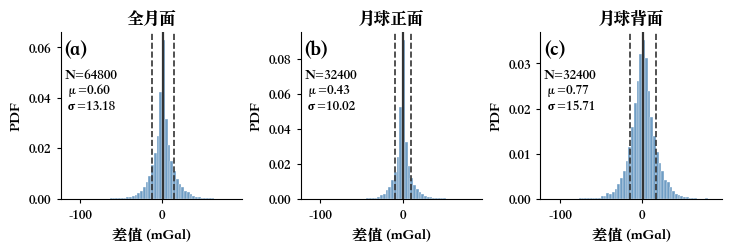

In [153]:
res = split_near_far(diffbouguer)

Z_flat,        W_flat        = res['all']['Z'],  res['all']['W']
near_Z,        near_W        = res['near']['Z'], res['near']['W']
far_Z,         far_W         = res['far']['Z'],  res['far']['W']

Z_far_east,    W_far_east    = res['far_east']['Z'], res['far_east']['W']
Lon_far_east,  Lat_far_east  = res['far_east']['lon'], res['far_east']['lat']

Z_far_west,    W_far_west    = res['far_west']['Z'], res['far_west']['W']
Lon_far_west,  Lat_far_west  = res['far_west']['lon'], res['far_west']['lat']

# bin edges
bins = 60
bin_edges = np.linspace(np.nanmin(Z_flat), np.nanmax(Z_flat), bins + 1)

fig, axes = plt.subplots(
    1, 3,
    figsize=(7.2, 2.4),
    constrained_layout=True
)

plot_hist(axes[0], Z_flat, W_flat, '全月面', bin_edges, xlabel="差值 (mGal)")
plot_hist(axes[1], near_Z, near_W, '月球正面', bin_edges, xlabel="差值 (mGal)")
plot_hist(axes[2], far_Z, far_W, '月球背面', bin_edges, xlabel="差值 (mGal)")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

add_panel_label(axes[0], "(a)")
add_panel_label(axes[1], "(b)")
add_panel_label(axes[2], "(c)")

fig.savefig("figure/figure8_histglobalthickness.png", dpi=dpi)

plt.show()

## 9.diffvstopo

/var/folders/xb/p9yw1hp93wxfx_mg6rcxlhmr0000gn/T/ipykernel_45345/1328237609.py:64: UserWarning: Glyph 8211 (\N{EN DASH}) missing from font(s) Songti SC.
  plt.tight_layout()
/var/folders/xb/p9yw1hp93wxfx_mg6rcxlhmr0000gn/T/ipykernel_45345/1328237609.py:65: UserWarning: Glyph 8211 (\N{EN DASH}) missing from font(s) Songti SC.
  plt.savefig('figure/figure9_diffvstopo.png', dpi=dpi, bbox_inches='tight')
/opt/miniconda3/envs/geoenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8211 (\N{EN DASH}) missing from font(s) Songti SC.
  fig.canvas.print_figure(bytes_io, **kw)


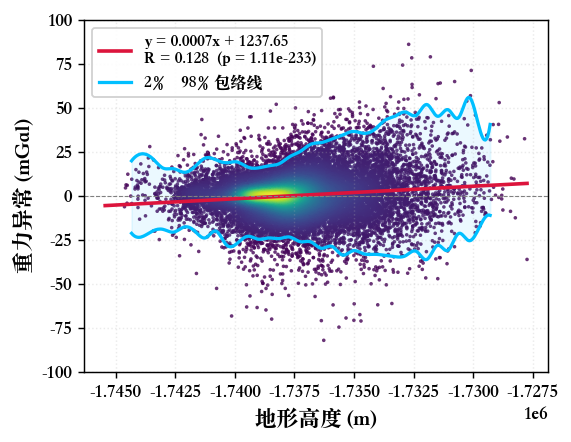

In [154]:
from scipy.stats import gaussian_kde, linregress
from scipy.interpolate import make_interp_spline
# ---- 数据 ----
topo_9 = topo.interp_like(diffbouguer)
topo_data = topo_9.values - bl.Moon2015.mean_radius

x = topo_data.flatten()
y = Z_flat

m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]

# ---- 密度着色 (抽样算 KDE) ----
rng = np.random.default_rng(0)
n_sample = min(20000, x.size)
idx = rng.choice(x.size, n_sample, replace=False)
xs, ys = x[idx], y[idx]
density = gaussian_kde(np.vstack([xs, ys]))(np.vstack([xs, ys]))
order = density.argsort()
xs, ys, density = xs[order], ys[order], density[order]

# ---- 线性拟合 ----
slope, intercept, r, p, _ = linregress(x, y)
x_line = np.array([x.min(), x.max()])
y_line = slope * x_line + intercept

# ---- 包络线 (按 x 分 bin 取分位数) ----
bins, q_low, q_high, min_count = 40, 0.02, 0.98, 30
edges = np.linspace(x.min(), x.max(), bins + 1)
centers, lo, hi = [], [], []
for i in range(bins):
    sel = (x >= edges[i]) & (x < edges[i+1])
    if sel.sum() >= min_count:
        centers.append(0.5*(edges[i]+edges[i+1]))
        lo.append(np.quantile(y[sel], q_low))
        hi.append(np.quantile(y[sel], q_high))
centers, lo, hi = map(np.array, (centers, lo, hi))

xs_sm = np.linspace(centers.min(), centers.max(), 300)
lo_sm = make_interp_spline(centers, lo, k=3)(xs_sm)
hi_sm = make_interp_spline(centers, hi, k=3)(xs_sm)

# ---- 画图 ----
fig, ax = plt.subplots(figsize=(4.5, 3.5), dpi=130)
ax.scatter(xs, ys, c=density, s=4, cmap='viridis',
           edgecolors='none', alpha=0.8, rasterized=True)

ax.plot(x_line, y_line, color='crimson', lw=2,
        label=f'y = {slope:.4f}x + {intercept:.2f}\nR = {r:.3f}  (p = {p:.2e})')
ax.plot(xs_sm, hi_sm, color='deepskyblue', lw=1.8, label='2%–98% 包络线')
ax.plot(xs_sm, lo_sm, color='deepskyblue', lw=1.8)
ax.fill_between(xs_sm, lo_sm, hi_sm, color='deepskyblue', alpha=0.08)

ax.axhline(0, color='gray', lw=0.6, ls='--')
ax.set_xlabel('地形高度 (m)', fontsize=12)
ax.set_ylabel('重力异常 (mGal)', fontsize=12)
ax.grid(alpha=0.25, ls=':')
ax.legend(loc='upper left', fontsize=9, frameon=True, framealpha=0.9)
for s in ax.spines.values():
    s.set_linewidth(0.8)

ax.set_ylim(-100,100)

plt.tight_layout()
plt.savefig('figure/figure9_diffvstopo.png', dpi=dpi, bbox_inches='tight')
plt.show()

## 10.densityandfinalgravity

In [155]:
df=pd.read_csv("density_gravity.csv")
lon = np.sort(df['lon'].unique())
lat = np.sort(df['lat'].unique())
rho         = df.pivot(index='lat', columns='lon', values='rho_anomaly') \
                .loc[lat, lon].values.astype(float)
gravity     = df.pivot(index='lat', columns='lon', values='gravity') \
                .loc[lat, lon].values.astype(float)


df         = pd.read_csv(fr'boueguer_frenquency_11km_d35km_1deg.csv')

lon = np.sort(df['lon'].unique())
lat = np.sort(df['lat'].unique())

go          = df.pivot(index='lat', columns='lon', values='deltaN') \
                .loc[lat, lon].values.astype(float)

rho_xr=xr.DataArray(rho,
                    dims=("lat","lon"),
                    coords={
                        "lat":lat,
                        "lon":lon
                    })
gravity_xr=xr.DataArray(gravity,
                    dims=("lat","lon"),
                    coords={
                        "lat":lat,
                        "lon":lon
                    })
go_raw_xr=xr.DataArray(go,
                   dims=("lat","lon"),
                    coords={
                        "lat":lat,
                        "lon":lon
                    })

go_xr=go_raw_xr-gravity_xr

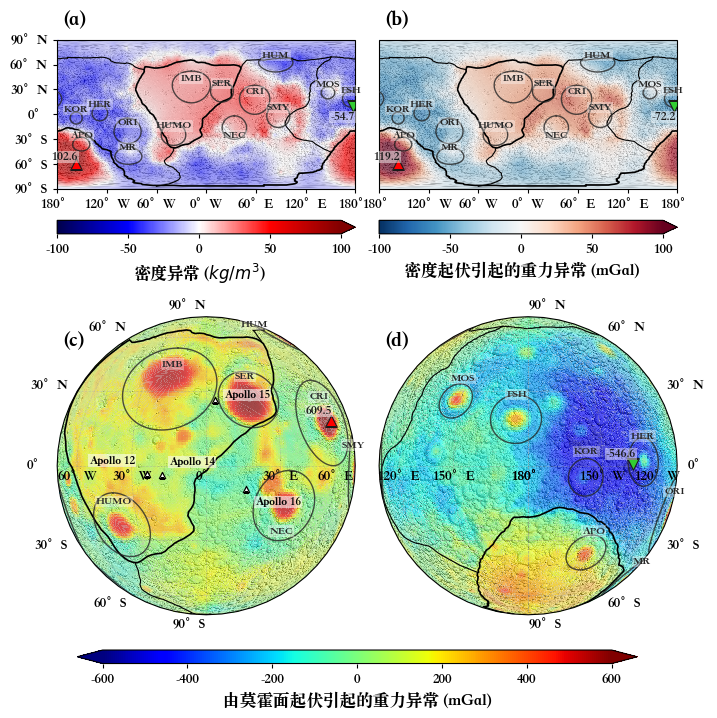

In [156]:
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

label_size=12
tickt_size=10

fig = plt.figure(figsize=(8, 9))
ls = LightSource(azdeg=315, altdeg=45)

dx = np.deg2rad(float(topo.lon.diff('lon').mean())) * 1737.4e3
dy = np.deg2rad(float(topo.lat.diff('lat').mean())) * 1737.4e3
hillshade = ls.hillshade(np.array(topo), vert_exag=10, dx=dx, dy=dy)

def add_hillshade(ax):
    ax.pcolormesh(topo.lon, topo.lat, hillshade,
                  transform=ccrs.PlateCarree(),
                  cmap='gray', vmin=0, vmax=1,
                  alpha=hillshade_alpha, shading='auto', zorder=2)

# ==================== 上排：PlateCarree 投影 ====================
ax1 = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree())
ax1.set_global()

v=100

pm1 = ax1.pcolormesh(rho_xr.lon, rho_xr.lat, rho_xr,
                     transform=ccrs.PlateCarree(),
                     cmap='seismic', shading="auto", vmin=-v, vmax=v, zorder=1)
add_hillshade(ax1)
add_panel_label(ax1, "(a)", y=1.2)
ax1.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
ax1.set_yticks(np.arange(-90, 91, 30),  crs=ccrs.PlateCarree())
lon_formatter = LongitudeFormatter(zero_direction_label=True)
lat_formatter = LatitudeFormatter()
ax1.xaxis.set_major_formatter(lon_formatter)
ax1.yaxis.set_major_formatter(lat_formatter)
ax1.tick_params(labelsize=tickt_size)
plot_boundaries_folder_on_ax(ax1, 'data',
                              thick_keywords=("SPATU", "MTU"),
                              linewidth_thick=1.2, linewidth_thin=0.8)

val_max, lon_max, lat_max, val_min, lon_min, lat_min = find_extreme(rho_xr)
for ax in [ax1]:
    mark_extreme(ax, lon_max, lat_max, val_max, "^", "red")
    mark_extreme(ax, lon_min, lat_min, val_min, "v", "limegreen",text_dy=-20)

ax2 = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree())
ax2.set_global()

pm2 = ax2.pcolormesh(gravity_xr.lon, gravity_xr.lat, gravity_xr,
                     transform=ccrs.PlateCarree(),
                     cmap='RdBu_r', shading="auto", vmin=-v, vmax=v, zorder=1)
add_hillshade(ax2)
add_panel_label(ax2, "(b)", y=1.2)
ax2.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
ax2.xaxis.set_major_formatter(lon_formatter)
ax2.tick_params(labelsize=tickt_size)
plot_boundaries_folder_on_ax(ax2, 'data',   # ← 修正了原来写成 ax1 的 bug
                              thick_keywords=("SPATU", "MTU"),
                              linewidth_thick=1.2, linewidth_thin=0.8)

val_max, lon_max, lat_max, val_min, lon_min, lat_min = find_extreme(gravity_xr)
for ax in [ax2]:
    mark_extreme(ax, lon_max, lat_max, val_max, "^", "red")
    mark_extreme(ax, lon_min, lat_min, val_min, "v", "limegreen",text_dy=-20)

# ==================== 下排：Orthographic 投影 ====================
ax3 = fig.add_subplot(2, 2, 3, projection=ccrs.Orthographic(central_longitude=0,   central_latitude=0))
ax4 = fig.add_subplot(2, 2, 4, projection=ccrs.Orthographic(central_longitude=180, central_latitude=0))
cmap='jet'
for ax in [ax3, ax4]:
    ax.set_global()
    ax.gridlines(xlocs=np.arange(-180, 181, 30),
                 ylocs=np.arange(-90,   91, 30),
                 draw_labels=False, linewidth=0.5,
                 color='gray', alpha=0.5, linestyle='--')

pm3 = ax3.pcolormesh(go_xr.lon, go_xr.lat, go_xr,
                     transform=ccrs.PlateCarree(),
                     cmap=cmap, shading="auto", zorder=1,vmax=600,vmin=-600)
add_hillshade(ax3)
add_panel_label(ax3, "(c)")

pm4 = ax4.pcolormesh(go_xr.lon, go_xr.lat, go_xr,
                     transform=ccrs.PlateCarree(),
                     cmap=cmap, shading="auto", zorder=1,vmax=600,vmin=-600)
add_hillshade(ax4)
add_panel_label(ax4, "(d)")

# 极值标记
val_max, lon_max, lat_max, val_min, lon_min, lat_min = find_extreme(go_xr)
for ax in [ax3, ax4]:
    mark_extreme(ax, lon_max, lat_max, val_max, "^", "red")
    mark_extreme(ax, lon_min, lat_min, val_min, "v", "limegreen")

# 经纬度标签
xlocs = np.arange(-180, 181, 30)
xlocs = xlocs[(xlocs != 90) & (xlocs != -90)]
ylocs = np.arange(-90, 91, 30)

label.add_lat_labels_on_limb(ax3, ylocs, side="left",  offset_frac=0.07, text_kwargs={"fontsize": 10})
label.add_lon_labels_on_equator(ax3, xlocs,                              text_kwargs={"fontsize": 10})
label.add_lat_labels_on_limb(ax4, ylocs, side="right", offset_frac=0.07, text_kwargs={"fontsize": 10})
label.add_lon_labels_on_equator(ax4, xlocs, central_lonlat=(180, 0),     text_kwargs={"fontsize": 10})

# 边界线
for ax in [ax3, ax4]:
    plot_boundaries_folder_on_ax(ax, 'data',
                                  thick_keywords=("SPATU", "MTU"),
                                  linewidth_thick=1.2, linewidth_thin=0.8)

# Apollo 站点（仅近侧）
label.plot_apollo_sites(ax3, apollo_sites, show_labels=True)

# 盆地
for (abbr, fullname, lat0, lon0, r_km) in basins:
    offside = (0, -10) if abbr == "NEC" else (0, 10)
    for ax in [ax1, ax2, ax3, ax4]:
        add_basin(ax, abbr, lat0, lon0, r_km,
                  lw=1, alpha=0.8, n_samples=100, label_offset=offside)
plt.subplots_adjust(hspace=0.15, wspace=0.08, bottom=0.15)
# 下排共用色标
cbar_ax = fig.add_axes([0.15, 0.1, 0.70, 0.015])
cbar = fig.colorbar(pm3, cax=cbar_ax, orientation='horizontal', aspect=40, extend="both")
cbar.set_label("由莫霍面起伏引起的重力异常 (mGal)", fontsize=label_size)
cbar.ax.tick_params(labelsize=tickt_size)

plt.subplots_adjust(hspace=0.15, wspace=0.08)

# 上排各自色标
for ax, pm, label_str in [(ax1, pm1, "密度异常 ($kg/m^3$)"),
                           (ax2, pm2, "密度起伏引起的重力异常 (mGal)")]:
    
    pos = ax.get_position()
    # 色标左边对齐 ax3，右边对齐 ax4
    cbar_ax = fig.add_axes([
        pos.x0,                        # left
        pos.y0 - 0.05,                 # bottom
        pos.x1 - pos.x0,               # width
        0.015                          # height
    ])
    cbar = fig.colorbar(pm, cax=cbar_ax, location='bottom', pad=0.06, shrink=0.95, aspect=40, extend='max')
    cbar.set_label(label_str, fontsize=label_size)


fig.savefig("figure/figure10_densityandfinalgravity.png", dpi=dpi, bbox_inches="tight")

## 11.spericalresult

In [157]:
# sperical harmonic domain inversion result
PROJECT_ROOT = Path.cwd().parent
data_filename="frequency_domain_run1.pkl"

with open(data_filename, "rb") as f:
    result = pickle.load(f)

thick = result["thick_grid"].data
nlat, nlon = thick.shape

lats = np.linspace(90, -90, nlat)
lons = np.linspace(0, 360, nlon, endpoint=False)

thick_da = xr.DataArray(thick, coords=[lats, lons], dims=["lat", "lon"])

# 转换到 [-180, 180] 并排序
da = thick_da.copy()
# lon = ((da.lon + 180) % 360) - 180
lon = da.lon
da = da.assign_coords(lon=lon).sortby("lon")

crustthick_spherical = da

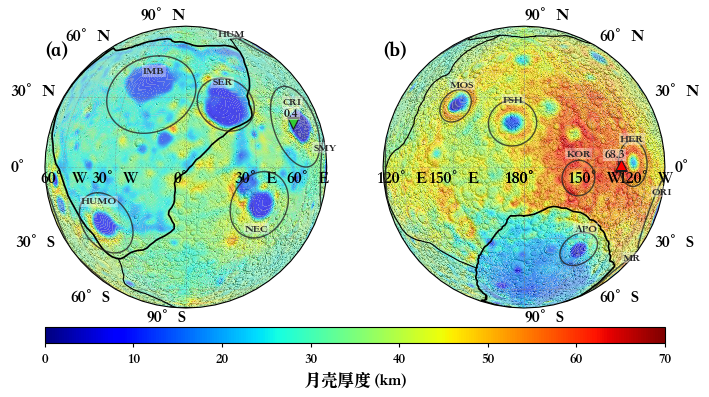

In [158]:
fig, axes, cbar = plot_hemisphere_pair(
    data_list=[crustthick_spherical],
    cmap='jet',
    cbar_label="月壳厚度 (km)",
    topo=topo,
    hillshade_alpha=0.35,
    mark_extremes=True,
    basins=basins,
    vmin=0,vmax=70,
    savepath="figure/figure11_spericalresult.png",
    dpi=dpi,
)

## 12. sphericalhistgolbal

In [159]:
res = split_near_far(crustthick_spherical)

Z_flat,        W_flat        = res['all']['Z'],  res['all']['W']
near_Z,        near_W        = res['near']['Z'], res['near']['W']
far_Z,         far_W         = res['far']['Z'],  res['far']['W']

Z_far_east,    W_far_east    = res['far_east']['Z'], res['far_east']['W']
Lon_far_east,  Lat_far_east  = res['far_east']['lon'], res['far_east']['lat']

Z_far_west,    W_far_west    = res['far_west']['Z'], res['far_west']['W']
Lon_far_west,  Lat_far_west  = res['far_west']['lon'], res['far_west']['lat']

# bin edges
bins = 60
bin_edges = np.linspace(np.nanmin(Z_flat), np.nanmax(Z_flat), bins + 1)

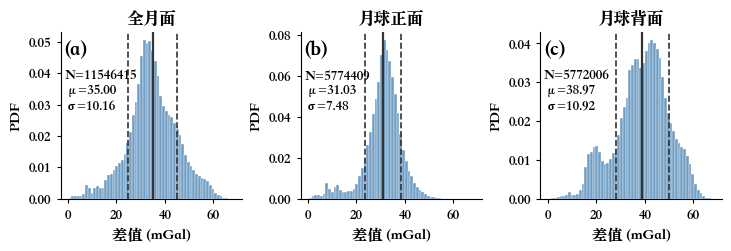

In [160]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(7.2, 2.4),
    constrained_layout=True
)

plot_hist(axes[0], Z_flat, W_flat, '全月面', bin_edges, xlabel="差值 (mGal)")
plot_hist(axes[1], near_Z, near_W, '月球正面', bin_edges, xlabel="差值 (mGal)")
plot_hist(axes[2], far_Z, far_W, '月球背面', bin_edges, xlabel="差值 (mGal)")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

add_panel_label(axes[0], "(a)")
add_panel_label(axes[1], "(b)")
add_panel_label(axes[2], "(c)")

fig.savefig("figure/figure12_sphericalhistgolbal.png", dpi=dpi)

plt.show()

## 13.sphericalhistfarside

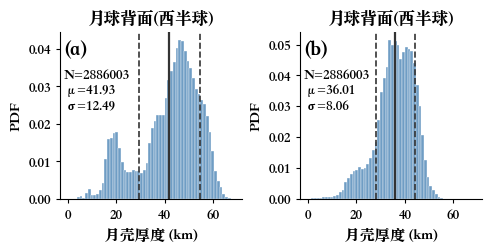

In [161]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(4.8, 2.4),
    constrained_layout=True
)

plot_hist(axes[0], Z_far_west, W_far_west, '月球背面(西半球)', bin_edges)
plot_hist(axes[1], Z_far_east, W_far_east, '月球背面(西半球)', bin_edges)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

add_panel_label(axes[0], "(a)")
add_panel_label(axes[1], "(b)")

fig.savefig("figure/figure13_sphericalhistfarside.png", dpi=dpi)

plt.show()

## 14.sphericalfarside3

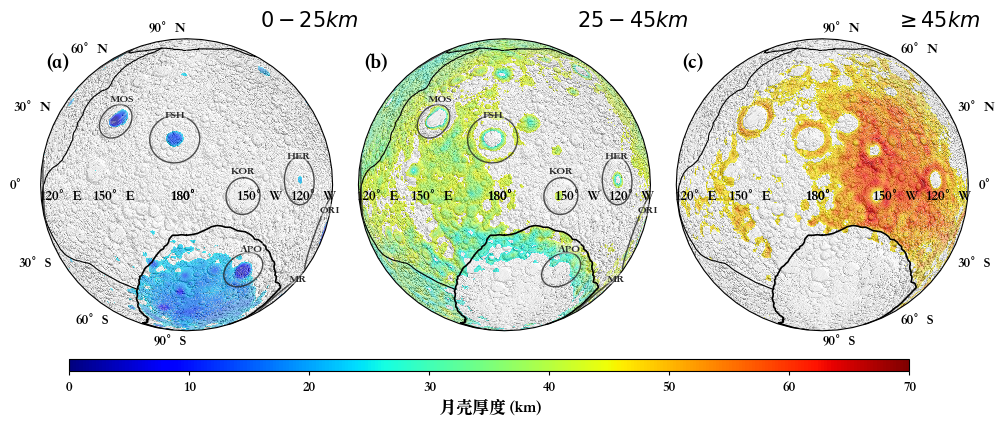

In [162]:
Z=crustthick_spherical.values

mask1=(Z>=0)&(Z<25)
mask2=(Z>=25)&(Z<45)
mask3=(Z>=45)

da1=crustthick_spherical.where(mask1)
da2=crustthick_spherical.where(mask2)
da3=crustthick_spherical.where(mask3)

fig=plt.figure(figsize=(12,4))

ax1 = fig.add_subplot(1, 3, 1, projection=ccrs.Orthographic(central_longitude=180,   central_latitude=0))
ax2 = fig.add_subplot(1, 3, 2, projection=ccrs.Orthographic(central_longitude=180,   central_latitude=0))
ax3 = fig.add_subplot(1, 3, 3, projection=ccrs.Orthographic(central_longitude=180,   central_latitude=0))

v=70
cmap='jet'

pm1 = ax1.pcolormesh(da1.lon, da1.lat, da1,
                     transform=ccrs.PlateCarree(),
                     cmap=cmap, shading="auto", zorder=0,vmax=v,vmin=0)
add_hillshade(ax1)
add_panel_label(ax1, "(a)")

pm2 = ax2.pcolormesh(da2.lon, da2.lat, da2,
                     transform=ccrs.PlateCarree(),
                     cmap=cmap, shading="auto", zorder=0,vmax=v,vmin=0)
add_hillshade(ax2)
add_panel_label(ax2, "(b)")

pm3 = ax3.pcolormesh(da3.lon, da3.lat, da3,
                     transform=ccrs.PlateCarree(),
                     cmap=cmap, shading="auto", zorder=0,vmax=v,vmin=0)
add_hillshade(ax3)
add_panel_label(ax3, "(c)")

add_panel_label(ax1, "$0-25km$", x=0.75,y=1.1)
add_panel_label(ax2, "$25-45km$", x=0.75,y=1.1)
add_panel_label(ax3, "$\geq45km$", x=0.75,y=1.1)

# 经纬度标签
xlocs = np.arange(-180, 181, 30)
xlocs = xlocs[(xlocs != 90) & (xlocs != -90)]
ylocs = np.arange(-90, 91, 30)

label.add_lat_labels_on_limb(ax1, ylocs, side="left",  offset_frac=0.07, text_kwargs={"fontsize": 10})
label.add_lon_labels_on_equator(ax1, xlocs, central_lonlat=(180, 0),     text_kwargs={"fontsize": 10})
label.add_lon_labels_on_equator(ax2, xlocs, central_lonlat=(180, 0),     text_kwargs={"fontsize": 10})
label.add_lat_labels_on_limb(ax3, ylocs, side="right", offset_frac=0.07, text_kwargs={"fontsize": 10})
label.add_lon_labels_on_equator(ax3, xlocs, central_lonlat=(180, 0),     text_kwargs={"fontsize": 10})

# 边界线
for ax in [ax1, ax2, ax3]:
    plot_boundaries_folder_on_ax(ax, 'data',
                                  thick_keywords=("SPATU", "MTU"),
                                  linewidth_thick=1.2, linewidth_thin=0.8)

# Apollo 站点（仅近侧）
label.plot_apollo_sites(ax1, apollo_sites, show_labels=True)

# 盆地
for (abbr, fullname, lat0, lon0, r_km) in basins:
    offside = (0, -10) if abbr == "NEC" else (0, 10)
    for ax in [ax1, ax2]:
        add_basin(ax, abbr, lat0, lon0, r_km,
                  lw=1, alpha=0.8, n_samples=100, label_offset=offside)
plt.subplots_adjust(hspace=0.15, wspace=0.08, bottom=0.15)
# 下排共用色标
cbar_ax = fig.add_axes([0.15, 0.05, 0.70, 0.03])
cbar = fig.colorbar(pm1, cax=cbar_ax, orientation='horizontal', aspect=20)
cbar.set_label("月壳厚度 (km)", fontsize=label_size)
cbar.ax.tick_params(labelsize=tickt_size)

plt.subplots_adjust(hspace=0.15, wspace=0.08)
fig.savefig("figure/figure14_sphericalfarside3.png", dpi=dpi, bbox_inches="tight")

## 15. sphericaleequator

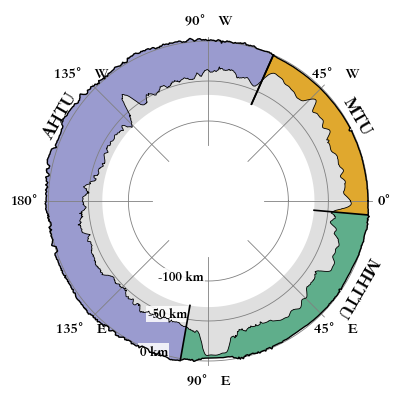

In [163]:
from matplotlib.patches import Wedge

# ==== 参数 ====
R0 = bl.Moon2015.mean_radius / 1000.0
rings = [-100, -50, 0]

# ==== 1. 取赤道一圈的月壳厚度 ====
eq = crustthick_spherical.sel(lat=0, method='nearest')
lon = np.asarray(eq['lon'])
thickness_km = np.asarray(eq.values)

moho_r = R0 - thickness_km
try:
    topo_eq = topo.interp_like(eq).sel(lat=0, method='nearest')
    surf_r = R0 + np.asarray(topo_eq.values) / 1e3
except Exception:
    surf_r = np.full_like(moho_r, R0)

theta = np.deg2rad(-lon)
order  = np.argsort(theta)
theta  = theta[order]
moho_r = moho_r[order]
surf_r = surf_r[order]

# ==== 2. 画图 ====
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='polar')

ax.set_theta_zero_location('E')
ax.set_theta_direction(1)

# ---- 最厚层阴影环（最底层，透明灰）----
max_thick  = float(np.nanmax(thickness_km))
r_maxdepth = R0 - max_thick

ax.fill_between(np.r_[theta, theta[:1]],
                np.full(theta.size + 1, r_maxdepth),
                np.r_[surf_r, surf_r[:1]],
                facecolor='gray', alpha=0.25,
                edgecolor='none', zorder=0)

# ---- 月壳层 ----
ax.fill_between(theta, moho_r, surf_r, color='lightgray',
                edgecolor='none', zorder=1)

# ---- 构造单元 ----
units = [
    ('MTU',   -66,   5, '#e0a82e'),
    ('MHTTU',   5, 100, '#5fae8b'),
    ('AHTU',  100, 294, '#9a9bcf'),
]
for name, lon0, lon1, color in units:
    lons   = np.linspace(lon0, lon1, 400)
    ths    = np.deg2rad(-lons)
    surf_i = np.interp(ths, theta, surf_r, period=2*np.pi)
    moho_i = np.interp(ths, theta, moho_r, period=2*np.pi)
    ax.fill_between(ths, moho_i, surf_i, color=color, zorder=2,
                    edgecolor='none')

# ---- 描边 ----
ax.plot(np.r_[theta, theta[:1]], np.r_[surf_r, surf_r[:1]],
        color='black', lw=1.0, zorder=4)
ax.plot(np.r_[theta, theta[:1]], np.r_[moho_r, moho_r[:1]],
        color='black', lw=0.6, zorder=4)

# ---- 地体边界黑线（只画到最深圆）----
boundary_lons = sorted({lon0 for _, lon0, _, _ in units} |
                       {lon1 for _, _, lon1, _ in units})
for b in boundary_lons:
    ths_b  = np.deg2rad(-b)
    surf_b = np.interp(ths_b, theta, surf_r, period=2*np.pi)
    ax.plot([ths_b, ths_b], [r_maxdepth, surf_b],
            color='black', lw=1.2, zorder=7)

# ---- 参考圆 ----
phi = np.linspace(0, 2*np.pi, 361)
for d in rings:
    r = R0 + d
    ax.plot(phi, np.full_like(phi, r), color='gray', lw=0.6, zorder=3)
    ax.text(np.deg2rad(-110), r, f'{d} km',
            fontsize=10, ha='center', va='center',
            bbox=dict(fc='white', ec='none', alpha=0.85, pad=1))

# ---- 八等分辐射线 ----
for ang in range(0, 360, 45):
    ax.plot([np.deg2rad(-ang)]*2, [R0 - 130, R0 + 5],
            color='gray', lw=0.6, zorder=3)

# ---- 经度标签 ----
lon_labels = {
      0: '0°',     45: '45° E',   90: '90° E',  135: '135° E',
    180: '180°', -135: '135° W', -90: '90° W', -45: '45° W',
}
r_label = R0 + 25
for lon_deg, txt in lon_labels.items():
    ax.text(np.deg2rad(-lon_deg), r_label, txt,
            ha='center', va='center', fontsize=11)

# ---- 单元名 ----
unit_labels = [('MTU', -30), ('MHTTU', 30), ('AHTU', -150)]
for name, lon_c in unit_labels:
    ang = -lon_c
    rot = ang - 90 if np.cos(np.deg2rad(ang)) >= 0 else ang + 270
    ax.text(np.deg2rad(ang), R0 + 15, name,
            ha='center', va='center', fontsize=13,
            rotation=rot, rotation_mode='anchor')

# ---- 美化 ----
ax.set_ylim(R0 - 200, R0 + 40)     # 下限拉大让月壳环更大、上限压低让外圈贴边
ax.set_yticks([])
ax.set_xticks([])
ax.spines['polar'].set_visible(False)
ax.grid(False)

# 让 polar axes 在 figure 里占满
ax.set_position([0.02, 0.02, 0.96, 0.96])

plt.savefig('figure/figure15_sphericaleequator.png',
            dpi=dpi, bbox_inches='tight', pad_inches=0.05)
plt.show()

## 16.tesseroidinversioning

In [164]:
#PROJECT_ROOT = Path.cwd().parent
#pkl_file=PROJECT_ROOT/"result/moho_inversion_result_34.pkl"
pkl_file=r"moho_inversion_result_1deg_35km.pkl"

with open(pkl_file, "rb") as f:
    obj = pickle.load(f, encoding="latin1")

    refden_moho_grid = obj['moho_grid']
    predict = obj['predict']
    observe = obj['observe']
    residuals = obj['residuals']
    rms = obj['rms']
    lon = obj['LON']
    lat = obj['LAT']
    
nlat_moho, nlon_moho = refden_moho_grid.shape
lon_moho = np.linspace(lon.min(), lon.max(), nlon_moho)
lat_moho = np.linspace(lat.min(), lat.max(), nlat_moho)

moho_grid = xr.DataArray(
    refden_moho_grid,  # 如果图东西颠倒或拉伸，改为 refden_moho_grid.T
    dims=("lat", "lon"),
    coords={"lat": lat_moho, "lon": lon_moho}
)

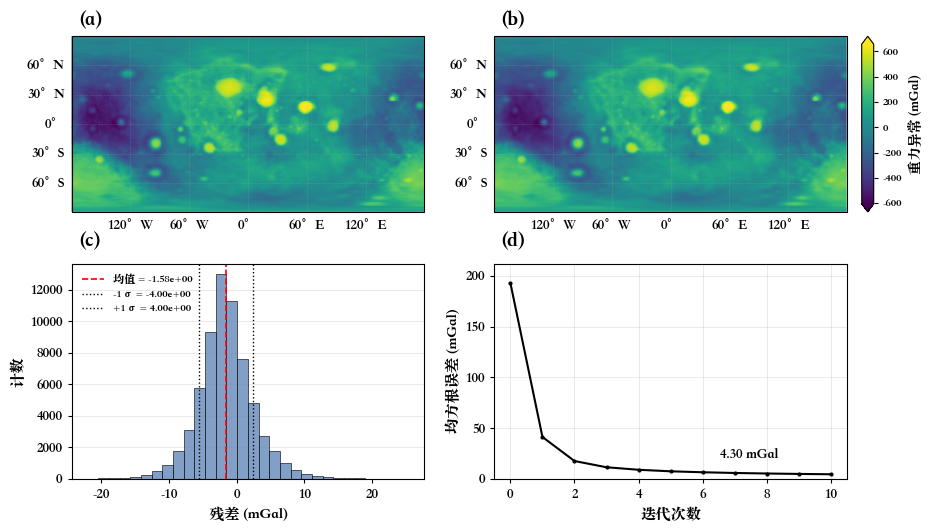

In [165]:
# ==== 数据准备 ====
predict = np.reshape(predict, [180, 360])
observe = np.reshape(observe, [180, 360])
nlat_p, nlon_p = predict.shape
lon_grid = np.linspace(lon.min(), lon.max(), nlon_p)
lat_grid = np.linspace(lat.min(), lat.max(), nlat_p)

predict_grid = xr.DataArray(predict, dims=("lat", "lon"),
                            coords={"lon": lon_grid, "lat": lat_grid})
observe_grid = xr.DataArray(observe, dims=("lat", "lon"),
                            coords={"lon": lon_grid, "lat": lat_grid})

def _wrap_sort_lon(lon, data_2d):
    lon = lon.astype(float)
    if np.nanmax(lon) > 180:
        lon_w = ((lon + 180) % 360) - 180
        idx = np.argsort(lon_w)
        return lon_w[idx], data_2d[:, idx]
    return lon, data_2d

lon_o, data_o = _wrap_sort_lon(observe_grid['lon'].values, observe_grid.values)
lon_p, data_p = _wrap_sort_lon(predict_grid['lon'].values, predict_grid.values)
lat_v = observe_grid['lat'].values

vmin = float(np.nanmin([data_o, data_p]))
vmax = float(np.nanmax([data_o, data_p]))

# ==== 画布 ====
fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(2, 2, hspace=0.15, wspace=0.2,
                      height_ratios=[1, 1])

# ---- (a) 观测 ----
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
ax1.set_extent([lon_o.min(), lon_o.max(), lat_v.min(), lat_v.max()],
               crs=ccrs.PlateCarree())
m1 = ax1.pcolormesh(lon_o, lat_v, data_o, transform=ccrs.PlateCarree(),
                    shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
gl1 = ax1.gridlines(draw_labels=True, linewidth=0.4, linestyle='--', alpha=0.3)
gl1.top_labels = gl1.right_labels = False
add_panel_label(ax1, '(a)', y=1.15)

# ---- (b) 预测 ----
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
ax2.set_extent([lon_p.min(), lon_p.max(), lat_v.min(), lat_v.max()],
               crs=ccrs.PlateCarree())
m2 = ax2.pcolormesh(lon_p, lat_v, data_p, transform=ccrs.PlateCarree(),
                    shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)

gl2 = ax2.gridlines(draw_labels=True, linewidth=0.4, linestyle='--', alpha=0.3)
gl2.top_labels = gl2.right_labels = False
add_panel_label(ax2, '(b)', y=1.15)

# ---- ab 共用 colorbar ----
fig.canvas.draw()
p1 = ax1.get_position()
p2 = ax2.get_position()

cax = fig.add_axes([p2.x1 + 0.015,           # 紧贴 b 右边
                    p1.y0,                    # 底对齐 a/b
                    0.012,                    # 宽度（窄）
                    p1.y1 - p1.y0])           # 高度等于 a/b 高度
cb = fig.colorbar(m1, cax=cax, orientation='vertical', extend='both')
cb.set_label('重力异常 (mGal)', fontsize=10)
cb.ax.tick_params(labelsize=8)

# ---- (c) 残差直方图 ----
ax3 = fig.add_subplot(gs[1, 0])
res = residuals.flatten()
mean_val = np.mean(res)
std_val  = np.std(res)
ax3.hist(res, bins=30, color='#6c8ebf', edgecolor='k',
         alpha=0.85, linewidth=0.5)
ax3.axvline(mean_val,           color='r', ls='--', lw=1.2,
            label=f'均值 = {mean_val:.2e}')
ax3.axvline(mean_val - std_val, color='k', ls=':',  lw=1.0,
            label=f'-1σ = {-std_val:.2e}')
ax3.axvline(mean_val + std_val, color='k', ls=':',  lw=1.0,
            label=f'+1σ = {std_val:.2e}')
ax3.set_xlabel('残差 (mGal)')
ax3.set_ylabel('计数')
ax3.legend(loc='upper left', frameon=False, fontsize=8)
ax3.grid(True, axis='y', linewidth=0.4, alpha=0.5)
ax3.set_axisbelow(True)
add_panel_label(ax3, '(c)', y=1.15)

# ---- (d) RMS 收敛曲线 ----
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(rms, '.-', color='black', markersize=6, lw=1.5, markeredgewidth=0)
last_iter, last_val = len(rms) - 1, rms[-1]
ax4.annotate(f'{last_val:.2f} mGal',
             xy=(last_iter, last_val),
             xytext=(last_iter - len(rms) * 0.15, last_val + 15),
             fontsize=10, color='black', ha='right')
ax4.set_xlabel('迭代次数')
ax4.set_ylabel('均方根误差 (mGal)')
ax4.set_ylim(0, max(200, np.nanmax(rms) * 1.1))
ax4.grid(True, linewidth=0.4, alpha=0.5)
ax4.set_axisbelow(True)
add_panel_label(ax4, '(d)', y=1.15)

plt.savefig('figure/空间域1P_合图.png', dpi=600, bbox_inches='tight')
plt.show()

## 17.tesseroidresult

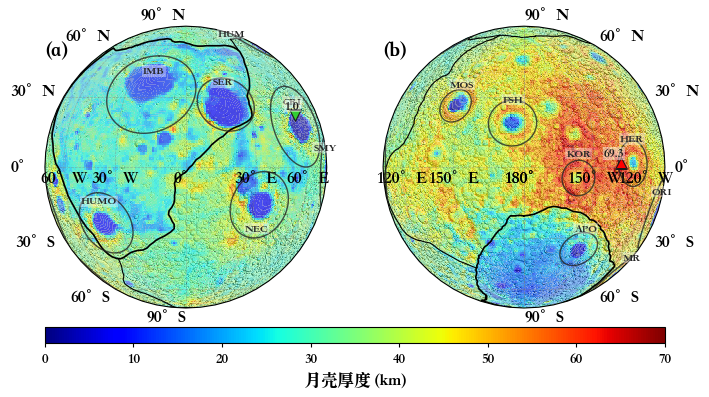

In [166]:
data_file = "boueguer_frenquency_11km_d35km_1deg.csv"

df = pd.read_csv(data_file)
lon_raw = np.sort(df['lon'].unique())
lat_raw = np.sort(df['lat'].unique())
nlat = len(np.unique(lat_raw))
nlon = len(np.unique(lon_raw))

topo_grid  = df.pivot(index='lat', columns='lon', values='topo').loc[lat_raw, lon_raw].values
LON, LAT = np.meshgrid(lon_raw, lat_raw) 

arr = topo_grid*1e-3

topo_da = xr.DataArray(
    arr,  # 如果图东西颠倒或拉伸，改为 refden_moho_grid.T
    dims=("lat", "lon"),
    coords={"lat": lat_raw, "lon": lon_raw}
)

region = [lon_raw.min(), lon_raw.max(), lat_raw.min(), lat_raw.max()]

topo_da=topo_da.interp_like(moho_grid)

crustthick=topo_da+moho_grid
crustthick_tesseroid = crustthick.where(crustthick >= 0)

fig, axes, cbar = plot_hemisphere_pair(
    data_list=[crustthick_tesseroid],
    cmap='jet',
    cbar_label="月壳厚度 (km)",
    topo=topo,
    hillshade_alpha=0.35,
    mark_extremes=True,
    basins=basins,
    vmin=0,vmax=70,
    savepath="figure/figure17_tesseroidresult.png",
    dpi=dpi,
)

## 18.tesseroidhistgolbal

In [167]:
res = split_near_far(crustthick_tesseroid)

Z_flat,        W_flat        = res['all']['Z'],  res['all']['W']
near_Z,        near_W        = res['near']['Z'], res['near']['W']
far_Z,         far_W         = res['far']['Z'],  res['far']['W']

Z_far_east,    W_far_east    = res['far_east']['Z'], res['far_east']['W']
Lon_far_east,  Lat_far_east  = res['far_east']['lon'], res['far_east']['lat']

Z_far_west,    W_far_west    = res['far_west']['Z'], res['far_west']['W']
Lon_far_west,  Lat_far_west  = res['far_west']['lon'], res['far_west']['lat']

# bin edges
bins = 60
bin_edges = np.linspace(np.nanmin(Z_flat), np.nanmax(Z_flat), bins + 1)

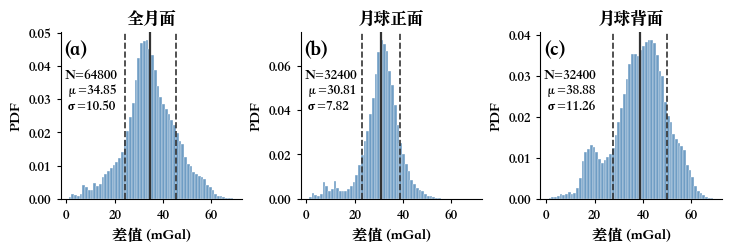

In [168]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(7.2, 2.4),
    constrained_layout=True
)

plot_hist(axes[0], Z_flat, W_flat, '全月面', bin_edges, xlabel="差值 (mGal)")
plot_hist(axes[1], near_Z, near_W, '月球正面', bin_edges, xlabel="差值 (mGal)")
plot_hist(axes[2], far_Z, far_W, '月球背面', bin_edges, xlabel="差值 (mGal)")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

add_panel_label(axes[0], "(a)")
add_panel_label(axes[1], "(b)")
add_panel_label(axes[2], "(c)")

fig.savefig("figure/figure18_tesseroidhistgolbal.png", dpi=dpi)

plt.show()

## 19.tesseroidhistfarside

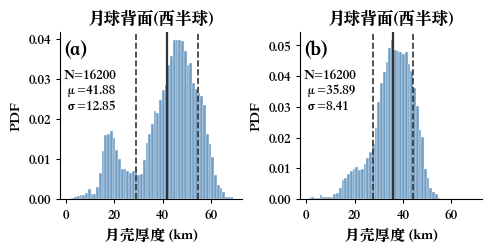

In [169]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(4.8, 2.4),
    constrained_layout=True
)

plot_hist(axes[0], Z_far_west, W_far_west, '月球背面(西半球)', bin_edges)
plot_hist(axes[1], Z_far_east, W_far_east, '月球背面(西半球)', bin_edges)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

add_panel_label(axes[0], "(a)")
add_panel_label(axes[1], "(b)")

fig.savefig("figure/figure19_tesseroidhistfarside.png", dpi=dpi)

plt.show()

## 20.tesseroidfarside3

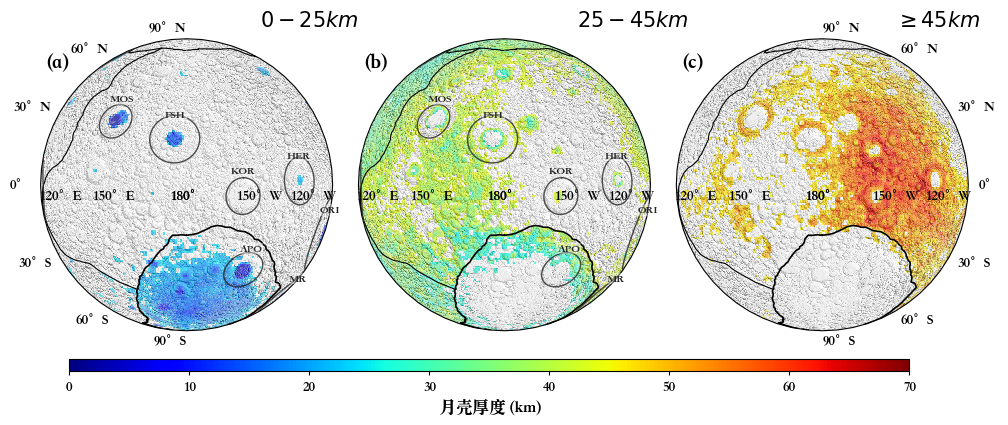

In [170]:
Z=crustthick_tesseroid.values

mask1=(Z>=0)&(Z<25)
mask2=(Z>=25)&(Z<45)
mask3=(Z>=45)

da1=crustthick_tesseroid.where(mask1)
da2=crustthick_tesseroid.where(mask2)
da3=crustthick_tesseroid.where(mask3)

fig=plt.figure(figsize=(12,4))

ax1 = fig.add_subplot(1, 3, 1, projection=ccrs.Orthographic(central_longitude=180,   central_latitude=0))
ax2 = fig.add_subplot(1, 3, 2, projection=ccrs.Orthographic(central_longitude=180,   central_latitude=0))
ax3 = fig.add_subplot(1, 3, 3, projection=ccrs.Orthographic(central_longitude=180,   central_latitude=0))

v=70
cmap='jet'

pm1 = ax1.pcolormesh(da1.lon, da1.lat, da1,
                     transform=ccrs.PlateCarree(),
                     cmap=cmap, shading="auto", zorder=0,vmax=v,vmin=0)
add_hillshade(ax1)
add_panel_label(ax1, "(a)")

pm2 = ax2.pcolormesh(da2.lon, da2.lat, da2,
                     transform=ccrs.PlateCarree(),
                     cmap=cmap, shading="auto", zorder=0,vmax=v,vmin=0)
add_hillshade(ax2)
add_panel_label(ax2, "(b)")

pm3 = ax3.pcolormesh(da3.lon, da3.lat, da3,
                     transform=ccrs.PlateCarree(),
                     cmap=cmap, shading="auto", zorder=0,vmax=v,vmin=0)
add_hillshade(ax3)
add_panel_label(ax3, "(c)")

add_panel_label(ax1, "$0-25km$", x=0.75,y=1.1)
add_panel_label(ax2, "$25-45km$", x=0.75,y=1.1)
add_panel_label(ax3, "$\geq45km$", x=0.75,y=1.1)

# 经纬度标签
xlocs = np.arange(-180, 181, 30)
xlocs = xlocs[(xlocs != 90) & (xlocs != -90)]
ylocs = np.arange(-90, 91, 30)

label.add_lat_labels_on_limb(ax1, ylocs, side="left",  offset_frac=0.07, text_kwargs={"fontsize": 10})
label.add_lon_labels_on_equator(ax1, xlocs, central_lonlat=(180, 0),     text_kwargs={"fontsize": 10})
label.add_lon_labels_on_equator(ax2, xlocs, central_lonlat=(180, 0),     text_kwargs={"fontsize": 10})
label.add_lat_labels_on_limb(ax3, ylocs, side="right", offset_frac=0.07, text_kwargs={"fontsize": 10})
label.add_lon_labels_on_equator(ax3, xlocs, central_lonlat=(180, 0),     text_kwargs={"fontsize": 10})

# 边界线
for ax in [ax1, ax2, ax3]:
    plot_boundaries_folder_on_ax(ax, 'data',
                                  thick_keywords=("SPATU", "MTU"),
                                  linewidth_thick=1.2, linewidth_thin=0.8)

# Apollo 站点（仅近侧）
label.plot_apollo_sites(ax1, apollo_sites, show_labels=True)

# 盆地
for (abbr, fullname, lat0, lon0, r_km) in basins:
    offside = (0, -10) if abbr == "NEC" else (0, 10)
    for ax in [ax1, ax2]:
        add_basin(ax, abbr, lat0, lon0, r_km,
                  lw=1, alpha=0.8, n_samples=100, label_offset=offside)
plt.subplots_adjust(hspace=0.15, wspace=0.08, bottom=0.15)
# 下排共用色标
cbar_ax = fig.add_axes([0.15, 0.05, 0.70, 0.03])
cbar = fig.colorbar(pm1, cax=cbar_ax, orientation='horizontal', aspect=20)
cbar.set_label("月壳厚度 (km)", fontsize=label_size)
cbar.ax.tick_params(labelsize=tickt_size)

plt.subplots_adjust(hspace=0.15, wspace=0.08)
fig.savefig("figure/figure20_tesseroidfarside3.png", dpi=dpi, bbox_inches="tight")

## 21.tesseroidequator

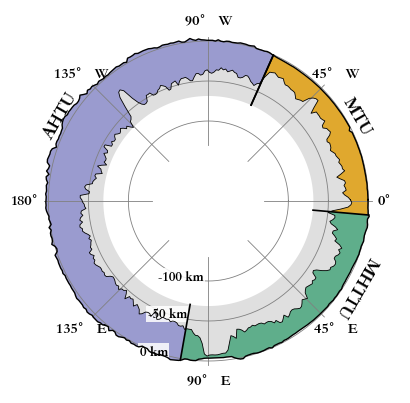

In [171]:
from matplotlib.patches import Wedge

# ==== 参数 ====
R0 = bl.Moon2015.mean_radius / 1000.0
rings = [-100, -50, 0]

# ==== 1. 取赤道一圈的月壳厚度 ====
eq = crustthick_tesseroid.sel(lat=0, method='nearest')
lon = np.asarray(eq['lon'])
thickness_km = np.asarray(eq.values)

moho_r = R0 - thickness_km
try:
    topo_eq = topo.interp_like(eq).sel(lat=0, method='nearest')
    surf_r = R0 + np.asarray(topo_eq.values) / 1e3
except Exception:
    surf_r = np.full_like(moho_r, R0)

theta = np.deg2rad(-lon)
order  = np.argsort(theta)
theta  = theta[order]
moho_r = moho_r[order]
surf_r = surf_r[order]

# ==== 2. 画图 ====
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='polar')

ax.set_theta_zero_location('E')
ax.set_theta_direction(1)

# ---- 最厚层阴影环（最底层，透明灰）----
max_thick  = float(np.nanmax(thickness_km))
r_maxdepth = R0 - max_thick

ax.fill_between(np.r_[theta, theta[:1]],
                np.full(theta.size + 1, r_maxdepth),
                np.r_[surf_r, surf_r[:1]],
                facecolor='gray', alpha=0.25,
                edgecolor='none', zorder=0)

# ---- 月壳层 ----
ax.fill_between(theta, moho_r, surf_r, color='lightgray',
                edgecolor='none', zorder=1)

# ---- 构造单元 ----
units = [
    ('MTU',   -66,   5, '#e0a82e'),
    ('MHTTU',   5, 100, '#5fae8b'),
    ('AHTU',  100, 294, '#9a9bcf'),
]
for name, lon0, lon1, color in units:
    lons   = np.linspace(lon0, lon1, 400)
    ths    = np.deg2rad(-lons)
    surf_i = np.interp(ths, theta, surf_r, period=2*np.pi)
    moho_i = np.interp(ths, theta, moho_r, period=2*np.pi)
    ax.fill_between(ths, moho_i, surf_i, color=color, zorder=2,
                    edgecolor='none')

# ---- 描边 ----
ax.plot(np.r_[theta, theta[:1]], np.r_[surf_r, surf_r[:1]],
        color='black', lw=1.0, zorder=4)
ax.plot(np.r_[theta, theta[:1]], np.r_[moho_r, moho_r[:1]],
        color='black', lw=0.6, zorder=4)

# ---- 地体边界黑线（只画到最深圆）----
boundary_lons = sorted({lon0 for _, lon0, _, _ in units} |
                       {lon1 for _, _, lon1, _ in units})
for b in boundary_lons:
    ths_b  = np.deg2rad(-b)
    surf_b = np.interp(ths_b, theta, surf_r, period=2*np.pi)
    ax.plot([ths_b, ths_b], [r_maxdepth, surf_b],
            color='black', lw=1.2, zorder=7)

# ---- 参考圆 ----
phi = np.linspace(0, 2*np.pi, 361)
for d in rings:
    r = R0 + d
    ax.plot(phi, np.full_like(phi, r), color='gray', lw=0.6, zorder=3)
    ax.text(np.deg2rad(-110), r, f'{d} km',
            fontsize=10, ha='center', va='center',
            bbox=dict(fc='white', ec='none', alpha=0.85, pad=1))

# ---- 八等分辐射线 ----
for ang in range(0, 360, 45):
    ax.plot([np.deg2rad(-ang)]*2, [R0 - 130, R0 + 5],
            color='gray', lw=0.6, zorder=3)

# ---- 经度标签 ----
lon_labels = {
      0: '0°',     45: '45° E',   90: '90° E',  135: '135° E',
    180: '180°', -135: '135° W', -90: '90° W', -45: '45° W',
}
r_label = R0 + 25
for lon_deg, txt in lon_labels.items():
    ax.text(np.deg2rad(-lon_deg), r_label, txt,
            ha='center', va='center', fontsize=11)

# ---- 单元名 ----
unit_labels = [('MTU', -30), ('MHTTU', 30), ('AHTU', -150)]
for name, lon_c in unit_labels:
    ang = -lon_c
    rot = ang - 90 if np.cos(np.deg2rad(ang)) >= 0 else ang + 270
    ax.text(np.deg2rad(ang), R0 + 15, name,
            ha='center', va='center', fontsize=13,
            rotation=rot, rotation_mode='anchor')

# ---- 美化 ----
ax.set_ylim(R0 - 200, R0 + 40)     # 下限拉大让月壳环更大、上限压低让外圈贴边
ax.set_yticks([])
ax.set_xticks([])
ax.spines['polar'].set_visible(False)
ax.grid(False)

# 让 polar axes 在 figure 里占满
ax.set_position([0.02, 0.02, 0.96, 0.96])

plt.savefig('figure/figure21_tesseroidequator.png',
            dpi=dpi, bbox_inches='tight', pad_inches=0.05)
plt.show()

## 22.diffresults

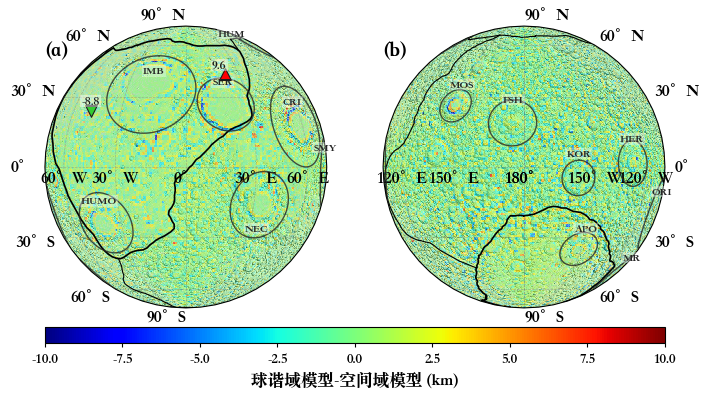

In [172]:
cal_crustal_spherical=crustthick_spherical.interp_like(crustthick_tesseroid)

diff_result=cal_crustal_spherical-crustthick_tesseroid

fig, axes, cbar = plot_hemisphere_pair(
    data_list=[diff_result],
    cmap='jet',
    cbar_label="球谐域模型-空间域模型 (km)",
    topo=topo,
    hillshade_alpha=0.35,
    mark_extremes=True,
    basins=basins,
    vmin=-10,vmax=10,
    savepath="figure/figure22_diffresults.png",
    dpi=dpi,
)

## 23.diffhistresult

In [173]:
res = split_near_far(diff_result)

Z_flat,        W_flat        = res['all']['Z'],  res['all']['W']
near_Z,        near_W        = res['near']['Z'], res['near']['W']
far_Z,         far_W         = res['far']['Z'],  res['far']['W']

Z_far_east,    W_far_east    = res['far_east']['Z'], res['far_east']['W']
Lon_far_east,  Lat_far_east  = res['far_east']['lon'], res['far_east']['lat']

Z_far_west,    W_far_west    = res['far_west']['Z'], res['far_west']['W']
Lon_far_west,  Lat_far_west  = res['far_west']['lon'], res['far_west']['lat']

# bin edges
bins = 60
bin_edges = np.linspace(np.nanmin(Z_flat), np.nanmax(Z_flat), bins + 1)

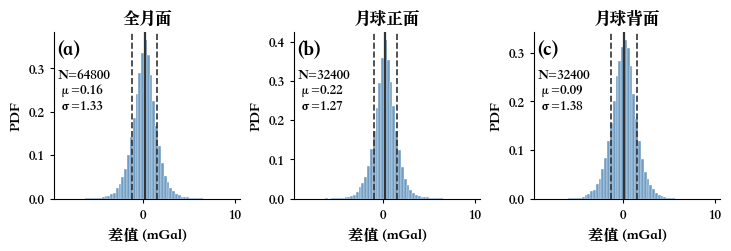

In [174]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(7.2, 2.4),
    constrained_layout=True
)

plot_hist(axes[0], Z_flat, W_flat, '全月面', bin_edges, xlabel="差值 (mGal)")
plot_hist(axes[1], near_Z, near_W, '月球正面', bin_edges, xlabel="差值 (mGal)")
plot_hist(axes[2], far_Z, far_W, '月球背面', bin_edges, xlabel="差值 (mGal)")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

add_panel_label(axes[0], "(a)")
add_panel_label(axes[1], "(b)")
add_panel_label(axes[2], "(c)")

fig.savefig("figure/figure23_diffhistresult.png", dpi=dpi)

plt.show()